In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the housing prices dataset from the CSV file
df = pd.read_csv("housing_prices_data.csv")

# 2. Display statistical summaries like mean and standard deviation for the data
print(df.describe())

# 3. Convert the entire DataFrame into a NumPy array for compatibility with TensorFlow
dataset = df.values

# 4. Separate the first 10 columns as input features (X) and the last column as the label (y)
X = dataset[:, 0:10]
y = dataset[:, 10]

# 5. Standardize the data so all features have a similar order of magnitude
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Partition the data into Training (70%), Validation (15%), and Test (15%) sets
# We split twice: first to get the test set, then to split the remainder into train/val
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 7. Print the shapes of the final datasets to verify the partitioning
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

             LotArea  OverallQual  OverallCond  TotalBsmtSF     FullBath  \
count    1460.000000  1460.000000  1460.000000  1460.000000  1460.000000   
mean    10516.828082     6.099315     5.575342  1057.429452     1.565068   
std      9981.264932     1.382997     1.112799   438.705324     0.550916   
min      1300.000000     1.000000     1.000000     0.000000     0.000000   
25%      7553.500000     5.000000     5.000000   795.750000     1.000000   
50%      9478.500000     6.000000     5.000000   991.500000     2.000000   
75%     11601.500000     7.000000     6.000000  1298.250000     2.000000   
max    215245.000000    10.000000     9.000000  6110.000000     3.000000   

          HalfBath  BedroomAbvGr  TotRmsAbvGrd   Fireplaces   GarageArea  \
count  1460.000000   1460.000000   1460.000000  1460.000000  1460.000000   
mean      0.382877      2.866438      6.517808     0.613014   472.980137   
std       0.502885      0.815778      1.625393     0.644666   213.804841   
min       0

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2642 - val_loss: 0.1444
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1531 - val_loss: 0.1144
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1200 - val_loss: 0.0984
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1059 - val_loss: 0.0912
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0958 - val_loss: 0.0857
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0899 - val_loss: 0.0818
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0859 - val_loss: 0.0787
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0825 - val_loss: 0.0789
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0798 - val_loss: 0.0768
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0765 - val_loss: 0.0739
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0745 - val_loss: 0.0720
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

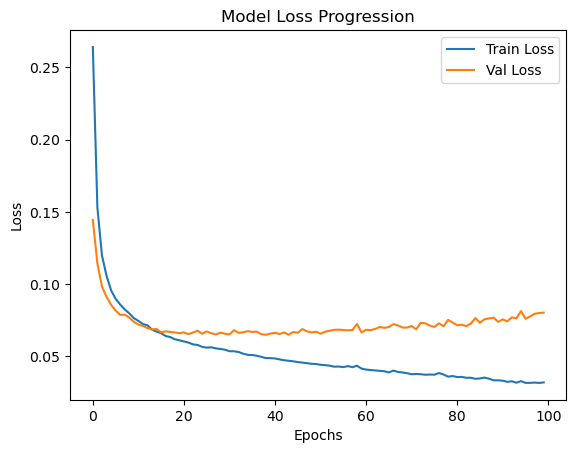

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 8. Building the Deep Network 
# We use a Sequential model to stack layers linearly
model = Sequential([
    Input(shape=(10,)),           # Input layer matching the 10 features
    Dense(32, activation='relu'),  # Hidden Layer 1 with 32 neurons
    Dense(32, activation='relu'),  # Hidden Layer 2 with 32 neurons
    Dense(1)                       # Output Layer (1 neuron for price prediction)
])

# 9. Compiling the Model
# Adam is chosen for its efficient adaptive learning rate
# MSE is the standard loss function for regression tasks
model.compile(optimizer='adam', loss='mean_squared_error')

# 10. Training the Model
# Training on the training set while monitoring validation data
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, verbose=1)

# 11. Evaluating the Model
# Testing performance on the unseen test set
test_loss = model.evaluate(X_test, y_test)
print(f"Final Test Loss (MSE): {test_loss}")

# 12. Visualizing Losses
# Plotting both curves to identify if the model is learning or overfitting
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()